Vamos a construir un proceso completo de entrenamiento de una red neuronal. Para ello desarrollaremos varios pasos:

a) La captura o carga de los datos

Los Dateset son contenedores que traen los datos desde la localización específica y permiten iterar a través de ellos por medio de iteradores tradicionales de Python

In [23]:
import torch
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,)),])
training_data = datasets.FashionMNIST(root="data",train=True,download=True,transform=ToTensor())
#test_data = datasets.FashionMNIST(root="data",train=False,download=True,transform=ToTensor())

# Descargar normalmente
mnist_trainset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

mnist_testset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

X_train = torch.stack([x for x, _ in mnist_trainset]).to(device)
y_train = torch.tensor([y for _, y in mnist_trainset], device=device)

X_test = torch.stack([x for x, _ in mnist_testset]).to(device)
y_test = torch.tensor([y for _, y in mnist_testset], device=device)

train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=2048,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=500,
    shuffle=False
)

print(device)


cuda:0


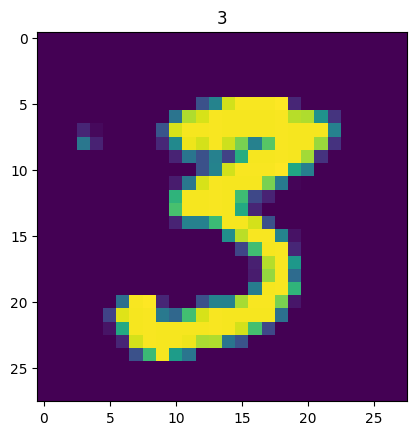

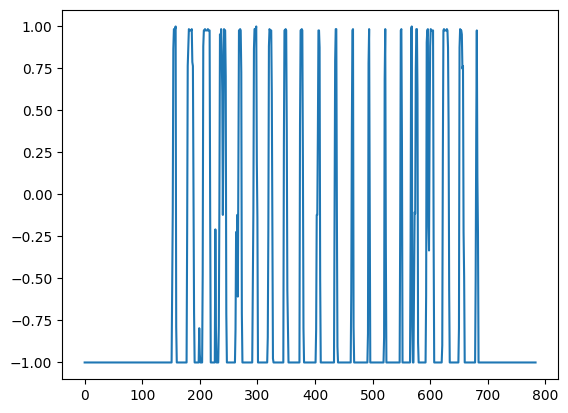

In [24]:
xi, yi=mnist_trainset[49]
xi.shape
img=xi[0,:,:].numpy()
plt.imshow(img)
plt.title(str(yi))

xi=xi.reshape(28*28,1)
plt.figure()
plt.plot(xi)

Ahora definiremos los parámetros del modelo, así como el modelo mismo

In [25]:
batch_size_train = 2000
learning_rate = 0.01

model=torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(28*28,100),
    torch.nn.ReLU(),
    torch.nn.Linear(100,50),
    torch.nn.ReLU(),
    torch.nn.Linear(50,10),
    torch.nn.ReLU()
).to(device)

cross_el = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9) #e-1
epoch = 1000



In [ ]:
import time
for epoch in range(epoch):
    start_time = time.time()
    for data in train_loader:      #for data in enumerate(train_loader):
        x, y = data                #    batch, (x,y)= data
        optimizer.zero_grad()
        output = model(x)
        loss = cross_el(output, y)
        loss.backward()
        optimizer.step()
    end_time = time.time()
    print(f'epoch: {epoch}, Error actual: {loss.item()}, Tiempo de proceso: {end_time-start_time}')

epoch: 0, Error actual: 2.2845211029052734, Tiempo de proceso: 0.6296117305755615
epoch: 1, Error actual: 2.262352705001831, Tiempo de proceso: 0.6195235252380371
epoch: 2, Error actual: 2.2390663623809814, Tiempo de proceso: 0.6060256958007812
epoch: 3, Error actual: 2.1705434322357178, Tiempo de proceso: 0.45148348808288574
epoch: 4, Error actual: 2.0997982025146484, Tiempo de proceso: 0.6091113090515137
epoch: 5, Error actual: 2.0428757667541504, Tiempo de proceso: 0.6042971611022949
epoch: 6, Error actual: 1.9505934715270996, Tiempo de proceso: 0.4723048210144043
epoch: 7, Error actual: 1.8694549798965454, Tiempo de proceso: 0.6146218776702881
epoch: 8, Error actual: 1.7912225723266602, Tiempo de proceso: 0.620182991027832
epoch: 9, Error actual: 1.7267732620239258, Tiempo de proceso: 0.598752498626709
epoch: 10, Error actual: 1.609522819519043, Tiempo de proceso: 0.44590306282043457
epoch: 11, Error actual: 1.5179346799850464, Tiempo de proceso: 0.5967333316802979
epoch: 12, Error

In [ ]:
#Verificación del comportamiento del modelo
#Primero comprendamos el modelo.
x, y = next(iter(test_loader))
output = model(x.to(device))
print('Dimensión de la entrada: ',x.shape)
print('Dimensión del target: ',y.shape)
print('Dimensión de la salida: ',output.shape)

print('Target: ',y[0:4])
print('Salida de la red: ',output[0:4])
out=torch.argmax(output, dim=1)
print('Salida: ',out[0:4])

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y.cpu().numpy(), out.cpu().numpy())
print(cm)

In [ ]:
#Ahora si una verificación un poco más seria
target=[]
pred=[]

for x, y in test_loader:
  output = model(x)
  out=torch.argmax(output, dim=1)
  target=target+list(y.numpy())
  pred=pred+list(out.numpy())

cm=confusion_matrix(target, pred, labels=[0,1,2,3,4,5,6,7,8,9])
print(cm)

#Por ejemplo las métricas respecto a la predicción del 0 o a cualquier otro valor
TP,TN,FP,FN=0,0,0,0
ref=0
for ti, pi in zip(target, pred):
  if(ti==ref and pi==ref):
    TP+=1
  if(ti==ref and pi!=ref):
    FN+=1
  if(ti!=ref and pi==ref):
    FP+=1
  if(ti!=ref and pi!=ref):
    TN+=1
print('TP: ',TP, ', TN: ',TN, ', FP: ',FP,', FN: ',FN)
print('Accuracy: ',(TP+TN)/(TP+TN+FP+FN))
TPR=TP/(TP+FN)
FPR=FP/(TN+FP)
print('TPR: ',TPR,', FPR: ',FPR)
TNR=1-FPR
print('Balanced Accuracy: ',(TPR+TNR)/2)


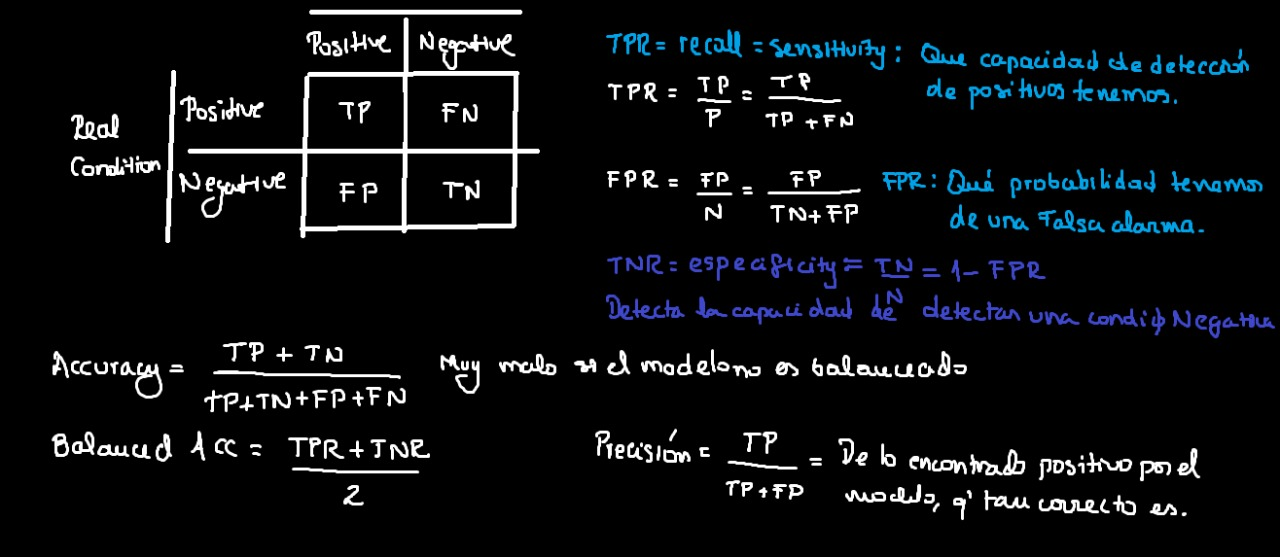